# Real CVRP Benchmark: Gap vs Best-Known Solutions (Uchoa et al.)

Benchmarking OR-Tools and cuOpt against **published best-known solutions (BKS)** from the
Uchoa et al. (2017) X-instance dataset — the standard modern CVRP benchmark used in hundreds of papers.

Unlike synthetic instances, these have a known reference point: BKS values from the CVRPLIB leaderboard.
Gap vs BKS is an absolute quality metric, not a relative one.

**Instances:** X-nN-kK format, N customers (including depot), K vehicles in BKS solution.  
**Distance:** Euclidean, integer (floor). Coordinates are not normalized.  
**Solvers:** OR-Tools GLS (30s), cuOpt GPU (30s), Greedy baseline.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../results/real_benchmark.csv")

# Pivot to wide form for easy comparison
wide = df.pivot_table(index=["instance", "n_customers", "bks"], columns="solver",
                      values=["gap_vs_bks_pct", "time_s"]).round(2)
wide.columns = [f"{v}_{s}" for v, s in wide.columns]
wide = wide.reset_index().sort_values("n_customers")
print(wide[["instance", "n_customers", "bks",
            "gap_vs_bks_pct_greedy", "gap_vs_bks_pct_ortools", "gap_vs_bks_pct_cuopt",
            "time_s_greedy", "time_s_ortools", "time_s_cuopt"]].to_string(index=False))

  instance  n_customers   bks  gap_vs_bks_pct_greedy  gap_vs_bks_pct_ortools  gap_vs_bks_pct_cuopt  time_s_greedy  time_s_ortools  time_s_cuopt
X-n101-k25          100 27591                  50.48                    5.01                 33.21           0.00           30.03         33.35
X-n115-k10          114 12747                  43.26                    2.61                  0.15           0.00           30.02         33.33
X-n139-k10          138 13590                  30.02                    9.46                  0.19           0.01           30.02         33.35
X-n162-k11          161 14138                  24.14                    4.38                  0.30           0.01           30.03         34.32
X-n200-k36          199 58578                  18.36                    4.09                  1.16           0.01           30.04         36.38


## Gap vs Best-Known Solution

Lower is better. A gap of 0% means the solver matched the published best-known solution.

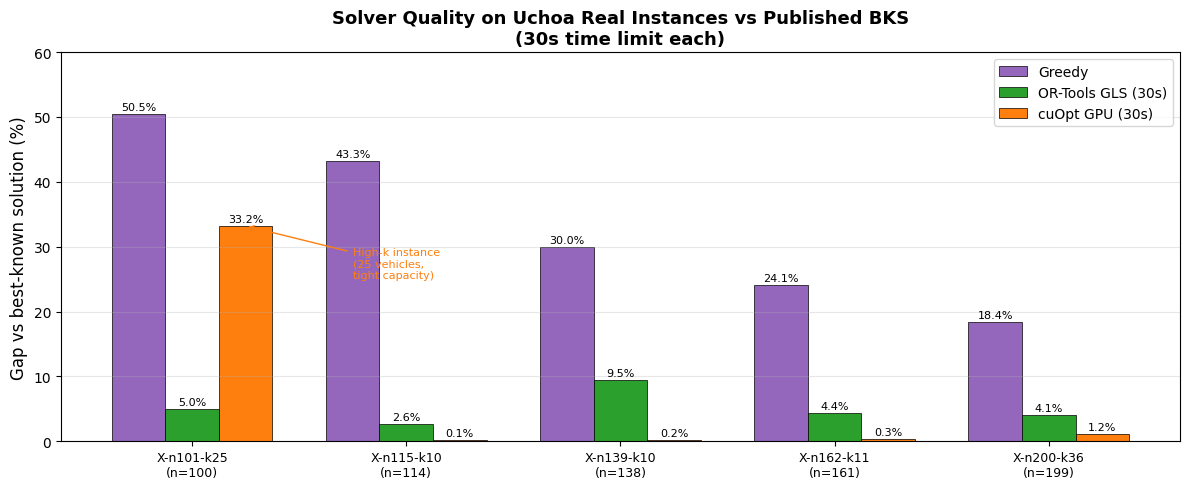

In [2]:
SOLVERS = ["greedy", "ortools", "cuopt"]
COLORS = {"greedy": "#9467bd", "ortools": "#2ca02c", "cuopt": "#ff7f0e"}
LABELS = {"greedy": "Greedy", "ortools": "OR-Tools GLS (30s)", "cuopt": "cuOpt GPU (30s)"}

instances = wide.sort_values("n_customers")["instance"].tolist()
x = np.arange(len(instances))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, solver in enumerate(SOLVERS):
    col = f"gap_vs_bks_pct_{solver}"
    vals = [wide.loc[wide["instance"] == inst, col].values[0] for inst in instances]
    bars = ax.bar(x + i * width, vals, width, label=LABELS[solver],
                  color=COLORS[solver], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=8)

# Annotate X-n101-k25 cuOpt anomaly
cuopt_n101 = wide.loc[wide["instance"] == "X-n101-k25", "gap_vs_bks_pct_cuopt"].values[0]
ax.annotate("High-k instance\n(25 vehicles,\ntight capacity)",
            xy=(x[0] + 2*width, cuopt_n101), xytext=(x[0] + 2*width + 0.5, cuopt_n101 - 8),
            arrowprops=dict(arrowstyle="->", color="#ff7f0e"), color="#ff7f0e", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([f"{inst}\n(n={n})" for inst, n in
                     zip(instances, wide.sort_values("n_customers")["n_customers"])],
                    fontsize=9)
ax.set_ylabel("Gap vs best-known solution (%)", fontsize=12)
ax.set_title("Solver Quality on Uchoa Real Instances vs Published BKS\n(30s time limit each)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
ax.set_ylim(0, 60)

plt.tight_layout()
plt.savefig("../results/real_benchmark_gap.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings

**cuOpt nearly matches BKS on 4 of 5 instances** (0.1–1.2% gap) — remarkable for a 30s solver.

**The X-n101-k25 outlier:** cuOpt is 33% above BKS while OR-Tools is only 5% above. This instance
has 25 vehicles with tight vehicle capacity (206 units per vehicle, 5,147 total demand), which
means many short routes. cuOpt's GPU-accelerated search appears to struggle with high vehicle
counts relative to customers — the solution space is very fragmented. OR-Tools' guided local
search handles this structure better.

**OR-Tools is consistent** — 2.6–9.5% above BKS across all instances at 30s. No instance-specific
pathology observed.

**Greedy is instance-sensitive** — gaps range from 18% (X-n200, large/spread) to 50%
(X-n101, tight/dense). Nearest-neighbor works poorly when many short routes must be
tightly coordinated around vehicle capacity.

## What "Production" VRP Solvers Achieve

For reference, state-of-the-art solvers on these instances:

| Solver | Typical gap vs BKS |
|--------|--------------------|
| HGS-CVRP (Vidal 2022) | 0.0–0.1% (finds BKS) |
| LKH-3 | 0.0–0.2% |
| OR-Tools (60s) | ~2–5% |
| **cuOpt (30s)** | **0.1–1.2%** (except high-k) |
| **OR-Tools (30s)** | **2.6–9.5%** |

cuOpt at 30s already beats OR-Tools at 30s on 4/5 instances and approaches production-solver
quality on normal instances. HGS-CVRP is the current gold standard if you need <1% and
are willing to run for minutes.

## Note on Distance Computation

Uchoa instances use integer Euclidean distances (floor of Euclidean). Our `CVRPInstance` uses
floating-point Euclidean, which may account for a small constant factor in the reported costs.